In [ ]:
#Gathering the Data saved from API
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json

data_file_director = '/content/drive/MyDrive/Colab Notebooks/Project/macro_data.json'
with open(data_file_director, 'r') as file:
  macro_file = file.read()

macro_data_all = json.loads(macro_file)

label_file_director = '/content/drive/MyDrive/Colab Notebooks/Project/volitility_index.json'
with open(label_file_director, 'r') as file:
  labels_file = file.read()

labels_data_all = json.loads(labels_file)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
list_of_dfs = []

for j_obj in macro_data_all:
  try:
    name = j_obj['name']
    date_form = j_obj['data']
    df = pd.DataFrame(date_form)
    df = df.rename(columns={'value' : name})
    list_of_dfs.append(df)
  except:
    print(j_obj)

In [ ]:
number_dataframe = len(list_of_dfs)

merged_dataframe = list_of_dfs[0]
for i in range(1, number_dataframe):
  merged_dataframe = merged_dataframe.merge(list_of_dfs[i], how='outer')

merged_dataframe

,date,Real Gross Domestic Product,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation - US Consumer Prices,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll
0,2021-01-01,19609.812,57889.0,1.08,0.09,261.582,4.69785886363739,3,79,462558,215529,6.4,140974
1,2020-01-01,18509.143,57279.0,1.76,1.55,257.971,1.23358439630637,2.5,99.8,416285,211354,3.5,150055
2,2019-01-01,19036.052,57100.0,2.71,2.40,251.712,1.81221007526015,2.7,91.2,399359,209313,4.0,147879
3,2018-01-01,18609.078,56195.0,2.58,1.41,247.867,2.44258329692818,2.7,95.7,389740,204291,4.0,145412
4,2017-01-01,18076.651,54866.0,2.43,0.65,242.839,2.13011000365963,2.6,98.5,369081,192661,4.7,143377
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,1913-05-01,NaN,NaN,NaN,NaN,9.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1313,1913-04-01,NaN,NaN,NaN,NaN,9.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1314,1913-03-01,NaN,NaN,NaN,NaN,9.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1315,1913-02-01,NaN,NaN,NaN,NaN,9.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
vix_file_directory = '/content/drive/MyDrive/Colab Notebooks/Project/VIX_History.csv'

vix_df = pd.read_csv(vix_file_directory)

def change_date_form(row):
  temp = str(row['DATE'])
  temp = temp.split('/')
  temp = temp[2] + '-' + temp[0] + '-' + temp[1]
  return temp

def mean_day_price(row):
  return (row['OPEN'] + row['HIGH'] + row['LOW'] + row['CLOSE']) / 4

# vix_df['date'] = vix_df.apply(lambda row: change_date_form(row), axis=1)
vix_df['Vix'] = vix_df.apply(lambda row: mean_day_price(row), axis=1)
vix_df = vix_df.drop(columns=['OPEN','HIGH','LOW','CLOSE'])
vix_df = vix_df.rename(columns={'DATE': 'date'})
vix_df

,date,Vix
0,01/02/1990,17.2400
1,01/03/1990,18.1900
2,01/04/1990,19.2200
3,01/05/1990,20.1100
4,01/08/1990,20.2600
...,...,...
8267,10/24/2022,30.3075
8268,10/25/2022,29.1200
8269,10/26/2022,27.8775
8270,10/27/2022,27.3775


In [ ]:
#section to convert date to unix time

import time
import datetime

def change_to_unix(date : str) -> int:
  try:
    t = time.mktime(datetime.datetime.strptime(date, "%Y-%m-%d").timetuple())
  except:
    t = time.mktime(datetime.datetime.strptime(date, "%m/%d/%Y").timetuple())
  return int(t)

def mod_df_time_unix(row):
  date_str = str(row['date'])
  unix = change_to_unix(date_str)
  return unix

In [ ]:
vix_df['unix'] = vix_df.apply(lambda row: mod_df_time_unix(row), axis=1)
vix_df = vix_df.rename(columns={'date': 'DATE'})
vix_df

,DATE,Vix,unix
0,01/02/1990,17.2400,631238400
1,01/03/1990,18.1900,631324800
2,01/04/1990,19.2200,631411200
3,01/05/1990,20.1100,631497600
4,01/08/1990,20.2600,631756800
...,...,...,...
8267,10/24/2022,30.3075,1666569600
8268,10/25/2022,29.1200,1666656000
8269,10/26/2022,27.8775,1666742400
8270,10/27/2022,27.3775,1666828800


In [ ]:
merged_dataframe['unix'] = merged_dataframe.apply(lambda row: mod_df_time_unix(row), axis=1)
merged_dataframe

,date,Real Gross Domestic Product,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation - US Consumer Prices,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll,unix
0,2021-01-01,19609.812,57889.0,1.08,0.09,261.582,4.69785886363739,3,79,462558,215529,6.4,140974,1609459200
1,2020-01-01,18509.143,57279.0,1.76,1.55,257.971,1.23358439630637,2.5,99.8,416285,211354,3.5,150055,1577836800
2,2019-01-01,19036.052,57100.0,2.71,2.40,251.712,1.81221007526015,2.7,91.2,399359,209313,4.0,147879,1546300800
3,2018-01-01,18609.078,56195.0,2.58,1.41,247.867,2.44258329692818,2.7,95.7,389740,204291,4.0,145412,1514764800
4,2017-01-01,18076.651,54866.0,2.43,0.65,242.839,2.13011000365963,2.6,98.5,369081,192661,4.7,143377,1483228800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,1913-05-01,NaN,NaN,NaN,NaN,9.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1788393600
1313,1913-04-01,NaN,NaN,NaN,NaN,9.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1790985600
1314,1913-03-01,NaN,NaN,NaN,NaN,9.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1793664000
1315,1913-02-01,NaN,NaN,NaN,NaN,9.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1796083200


In [ ]:
# vix_df = vix_df.drop(columns=['date'])
# merged_dataframe = merged_dataframe.drop(columns=['date'])

In [ ]:
all_data_df = pd.merge(vix_df, merged_dataframe, how='inner')
all_data_df

,DATE,Vix,unix,date,Real Gross Domestic Product,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation - US Consumer Prices,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll
0,02/01/1990,24.8700,633830400,1990-02-01,NaN,NaN,8.47,8.24,128.0,NaN,4.1,89.5,NaN,NaN,5.3,108069
1,03/01/1990,21.9000,636249600,1990-03-01,NaN,NaN,8.59,8.28,128.7,NaN,3.7,91.3,NaN,NaN,5.2,108724
2,05/01/1990,18.4300,641520000,1990-05-01,NaN,NaN,8.76,8.18,129.2,NaN,3.4,90.6,NaN,NaN,5.4,110270
3,06/01/1990,17.0900,644198400,1990-06-01,NaN,NaN,8.48,8.29,129.9,NaN,3.8,88.3,NaN,NaN,5.2,110837
4,08/01/1990,21.6400,649468800,1990-08-01,NaN,NaN,8.75,8.13,131.6,NaN,4.6,76.4,NaN,NaN,5.7,109449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,04/01/2022,20.1300,1648771200,2022-04-01,NaN,59756.0,2.75,0.33,289.109,NaN,5.4,65.2,594426,260366,3.6,150957
248,06/01/2022,26.2125,1654041600,2022-06-01,NaN,NaN,3.14,1.21,296.311,NaN,5.3,50,609933,294470,3.6,152607
249,07/01/2022,28.1275,1656633600,2022-07-01,NaN,60082.0,2.90,1.68,296.276,NaN,5.2,51.5,600746,249456,3.5,152258
250,08/01/2022,22.6950,1659312000,2022-08-01,NaN,NaN,2.90,2.33,296.171,NaN,4.8,58.2,612608,279237,3.7,152642


In [ ]:
all_data_df = all_data_df.fillna(method='ffill')
all_data_df = all_data_df.fillna(method='bfill')
all_data_df

,DATE,Vix,unix,date,Real Gross Domestic Product,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation - US Consumer Prices,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll
0,02/01/1990,24.8700,633830400,1990-02-01,NaN,37056.0,8.47,8.24,128.0,NaN,4.1,89.5,147175,123268,5.3,108069
1,03/01/1990,21.9000,636249600,1990-03-01,NaN,37056.0,8.59,8.28,128.7,NaN,3.7,91.3,147175,123268,5.2,108724
2,05/01/1990,18.4300,641520000,1990-05-01,NaN,37056.0,8.76,8.18,129.2,NaN,3.4,90.6,147175,123268,5.4,110270
3,06/01/1990,17.0900,644198400,1990-06-01,NaN,37056.0,8.48,8.29,129.9,NaN,3.8,88.3,147175,123268,5.2,110837
4,08/01/1990,21.6400,649468800,1990-08-01,NaN,37056.0,8.75,8.13,131.6,NaN,4.6,76.4,147175,123268,5.7,109449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,04/01/2022,20.1300,1648771200,2022-04-01,NaN,59756.0,2.75,0.33,289.109,NaN,5.4,65.2,594426,260366,3.6,150957
248,06/01/2022,26.2125,1654041600,2022-06-01,NaN,59756.0,3.14,1.21,296.311,NaN,5.3,50,609933,294470,3.6,152607
249,07/01/2022,28.1275,1656633600,2022-07-01,NaN,60082.0,2.90,1.68,296.276,NaN,5.2,51.5,600746,249456,3.5,152258
250,08/01/2022,22.6950,1659312000,2022-08-01,NaN,60082.0,2.90,2.33,296.171,NaN,4.8,58.2,612608,279237,3.7,152642


In [ ]:
all_data_df = all_data_df.dropna(axis=1)
all_data_df = all_data_df.drop(columns=['DATE','unix','date'])
all_data_df

,Vix,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll
0,24.8700,37056.0,8.47,8.24,128.0,4.1,89.5,147175,123268,5.3,108069
1,21.9000,37056.0,8.59,8.28,128.7,3.7,91.3,147175,123268,5.2,108724
2,18.4300,37056.0,8.76,8.18,129.2,3.4,90.6,147175,123268,5.4,110270
3,17.0900,37056.0,8.48,8.29,129.9,3.8,88.3,147175,123268,5.2,110837
4,21.6400,37056.0,8.75,8.13,131.6,4.6,76.4,147175,123268,5.7,109449
...,...,...,...,...,...,...,...,...,...,...,...
247,20.1300,59756.0,2.75,0.33,289.109,5.4,65.2,594426,260366,3.6,150957
248,26.2125,59756.0,3.14,1.21,296.311,5.3,50,609933,294470,3.6,152607
249,28.1275,60082.0,2.90,1.68,296.276,5.2,51.5,600746,249456,3.5,152258
250,22.6950,60082.0,2.90,2.33,296.171,4.8,58.2,612608,279237,3.7,152642


In [ ]:
all_data_df = all_data_df.astype('float')

for cols in all_data_df.columns:
  if cols == 'Vix':
    continue
  all_data_df[cols] = (all_data_df[cols] - all_data_df[cols].mean()) / all_data_df[cols].std() #Z normalize

all_data_df

,Vix,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll
0,24.8700,-1.747354,2.104877,2.358763,-1.706885,1.487951,0.259588,-1.448653,-1.736359,-0.316818,-1.977222
1,21.9000,-1.747354,2.164408,2.375697,-1.690589,0.910195,0.400117,-1.448653,-1.736359,-0.371204,-1.922829
2,18.4300,-1.747354,2.248743,2.333362,-1.678948,0.476878,0.345467,-1.448653,-1.736359,-0.262432,-1.794445
3,17.0900,-1.747354,2.109838,2.379930,-1.662652,1.054634,0.165902,-1.448653,-1.736359,-0.371204,-1.747359
4,21.6400,-1.747354,2.243783,2.312195,-1.623075,2.210146,-0.763150,-1.448653,-1.736359,-0.099275,-1.862623
...,...,...,...,...,...,...,...,...,...,...,...
247,20.1300,1.740431,-0.732756,-0.989909,2.043813,3.365659,-1.637553,2.406007,1.566105,-1.241375,1.584313
248,26.2125,1.740431,-0.539281,-0.617364,2.211479,3.221220,-2.824242,2.539655,2.387613,-1.241375,1.721333
249,28.1275,1.790519,-0.658343,-0.418391,2.210664,3.076781,-2.707135,2.460476,1.303301,-1.295760,1.692352
250,22.6950,1.790519,-0.658343,-0.143215,2.208219,2.499024,-2.184055,2.562710,2.020676,-1.186989,1.724240


array([13.681875, 23.245625, 35.89    ])

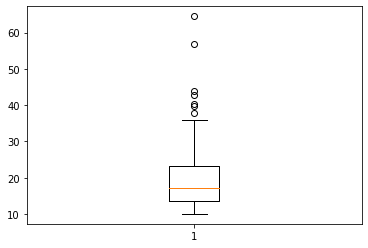

In [ ]:
vix_np = all_data_df[['Vix']].to_numpy().flatten()
whisker_box_vix = plt.boxplot(vix_np)
box_median = whisker_box_vix['medians'][0].get_ydata()[0]
box_quartiles = whisker_box_vix['boxes'][0].get_ydata()
low_quart = box_quartiles[0]
high_quart = box_quartiles[2]
box_caps_high = whisker_box_vix['caps'][1].get_ydata()[0]
boundaries_used = np.sort(np.array([low_quart,high_quart,box_caps_high]))
boundaries_used #1st quartile, 3rd quartile, and max whisker

In [ ]:
all_data_df['vix label'] =  np.where(all_data_df['Vix'] < boundaries_used[0], 1,
                            np.where(all_data_df['Vix'] < boundaries_used[1], 2,
                            np.where(all_data_df['Vix'] < boundaries_used[2], 3, 4)))
all_data_df

,Vix,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll,vix label
0,24.8700,-1.747354,2.104877,2.358763,-1.706885,1.487951,0.259588,-1.448653,-1.736359,-0.316818,-1.977222,3
1,21.9000,-1.747354,2.164408,2.375697,-1.690589,0.910195,0.400117,-1.448653,-1.736359,-0.371204,-1.922829,2
2,18.4300,-1.747354,2.248743,2.333362,-1.678948,0.476878,0.345467,-1.448653,-1.736359,-0.262432,-1.794445,2
3,17.0900,-1.747354,2.109838,2.379930,-1.662652,1.054634,0.165902,-1.448653,-1.736359,-0.371204,-1.747359,2
4,21.6400,-1.747354,2.243783,2.312195,-1.623075,2.210146,-0.763150,-1.448653,-1.736359,-0.099275,-1.862623,2
...,...,...,...,...,...,...,...,...,...,...,...,...
247,20.1300,1.740431,-0.732756,-0.989909,2.043813,3.365659,-1.637553,2.406007,1.566105,-1.241375,1.584313,2
248,26.2125,1.740431,-0.539281,-0.617364,2.211479,3.221220,-2.824242,2.539655,2.387613,-1.241375,1.721333,3
249,28.1275,1.790519,-0.658343,-0.418391,2.210664,3.076781,-2.707135,2.460476,1.303301,-1.295760,1.692352,3
250,22.6950,1.790519,-0.658343,-0.143215,2.208219,2.499024,-2.184055,2.562710,2.020676,-1.186989,1.724240,2


In [ ]:
all_data_df = all_data_df.drop(columns=['Vix'])
first_column = all_data_df.pop('vix label')
all_data_df.insert(0, 'vix label', first_column)
all_data_df

,vix label,Real Gross Domestic Product per Capita,10-Year Treasury Constant Maturity Rate,Effective Federal Funds Rate,Consumer Price Index for all Urban Consumers,Inflation Expectations,Consumer Sentiment & Consumer Confidence,Advance Retail Sales: Retail Trade,Manufacturer New Orders: Durable Goods,Unemployment Rate,Total Nonfarm Payroll
0,3,-1.747354,2.104877,2.358763,-1.706885,1.487951,0.259588,-1.448653,-1.736359,-0.316818,-1.977222
1,2,-1.747354,2.164408,2.375697,-1.690589,0.910195,0.400117,-1.448653,-1.736359,-0.371204,-1.922829
2,2,-1.747354,2.248743,2.333362,-1.678948,0.476878,0.345467,-1.448653,-1.736359,-0.262432,-1.794445
3,2,-1.747354,2.109838,2.379930,-1.662652,1.054634,0.165902,-1.448653,-1.736359,-0.371204,-1.747359
4,2,-1.747354,2.243783,2.312195,-1.623075,2.210146,-0.763150,-1.448653,-1.736359,-0.099275,-1.862623
...,...,...,...,...,...,...,...,...,...,...,...
247,2,1.740431,-0.732756,-0.989909,2.043813,3.365659,-1.637553,2.406007,1.566105,-1.241375,1.584313
248,3,1.740431,-0.539281,-0.617364,2.211479,3.221220,-2.824242,2.539655,2.387613,-1.241375,1.721333
249,3,1.790519,-0.658343,-0.418391,2.210664,3.076781,-2.707135,2.460476,1.303301,-1.295760,1.692352
250,2,1.790519,-0.658343,-0.143215,2.208219,2.499024,-2.184055,2.562710,2.020676,-1.186989,1.724240


In [ ]:
all_data_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Project/vix_macro.tsv", sep="\t", index=False)